In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [8]:
# Create dataset
X = np.linspace(-5,5,100).reshape(-1,1)
y = np.sin(X) + np.random.normal(0,0.1,(100,1))

# Activation
def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z>0).astype(float)

In [9]:

# SHALLOW NETWORK (1 hidden layer)

hidden = 5

W1 = np.random.randn(1,hidden)
b1 = np.zeros((1,hidden))

W2 = np.random.randn(hidden,1)
b2 = np.zeros((1,1))

lr = 0.01
epochs = 1000

for epoch in range(epochs):

    # forward
    z1 = X @ W1 + b1
    a1 = relu(z1)
    y_hat = a1 @ W2 + b2

    error = y - y_hat
    loss = np.mean(error**2)

    # backward
    dy = -2*error/len(X)

    dW2 = a1.T @ dy
    db2 = np.sum(dy,axis=0,keepdims=True)

    da1 = dy @ W2.T
    dz1 = da1 * relu_derivative(z1)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1,axis=0,keepdims=True)

    # update
    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

# predictions
y_shallow = relu(X@W1+b1)@W2 + b2

In [10]:

# DEEP NETWORK (2 hidden layers)


h1 = 5
h2 = 5

W1 = np.random.randn(1,h1)
b1 = np.zeros((1,h1))

W2 = np.random.randn(h1,h2)
b2 = np.zeros((1,h2))

W3 = np.random.randn(h2,1)
b3 = np.zeros((1,1))

for epoch in range(epochs):

    z1 = X@W1+b1
    a1 = relu(z1)

    z2 = a1@W2+b2
    a2 = relu(z2)

    y_hat = a2@W3+b3

    error = y - y_hat
    loss = np.mean(error**2)

    dy = -2*error/len(X)

    dW3 = a2.T@dy
    db3 = np.sum(dy,axis=0,keepdims=True)

    da2 = dy@W3.T
    dz2 = da2*relu_derivative(z2)

    dW2 = a1.T@dz2
    db2 = np.sum(dz2,axis=0,keepdims=True)

    da1 = dz2@W2.T
    dz1 = da1*relu_derivative(z1)

    dW1 = X.T@dz1
    db1 = np.sum(dz1,axis=0,keepdims=True)

    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2
    W3 -= lr*dW3
    b3 -= lr*db3

y_deep = relu(relu(X@W1+b1)@W2+b2)@W3+b3




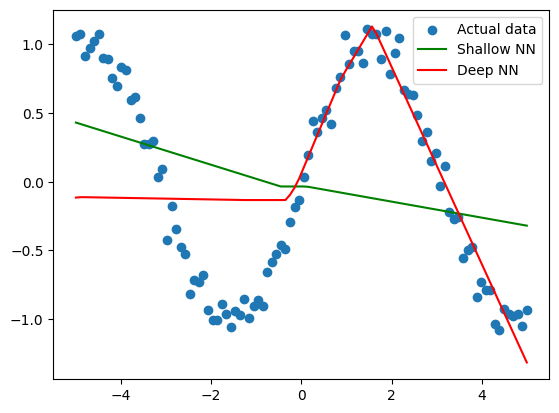

In [11]:

# Plot


plt.scatter(X,y,label="Actual data")
plt.plot(X,y_shallow,color='green',label="Shallow NN")
plt.plot(X,y_deep,color='red',label="Deep NN")
plt.legend()
plt.show()